In [ ]:
!pip install ultralytics lxml tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 86.7 MB/s eta 0:00:00


In [ ]:
import zipfile

zip_path = "archive.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset berhasil diekstrak")

Dataset berhasil diekstrak


In [ ]:
import os

for root, dirs, files in os.walk("dataset"):
    print(root, len(files))

dataset 0
dataset/train_zip 0
dataset/train_zip/train 480
dataset/test_zip 0
dataset/test_zip/test 120


In [ ]:
import shutil
import glob
import os

os.makedirs("fruit_dataset/images/train", exist_ok=True)
os.makedirs("fruit_dataset/images/val", exist_ok=True)

os.makedirs("fruit_dataset/labels/train", exist_ok=True)
os.makedirs("fruit_dataset/labels/val", exist_ok=True)

In [ ]:
import shutil
import glob
import os
import xml.etree.ElementTree as ET

# Define class mapping based on data.yaml
class_mapping = {
    'apple': 0,
    'orange': 1
}

def convert_xml_to_yolo(xml_file_path, output_dir, class_map):
    """
    Converts a PASCAL VOC XML annotation file to YOLO format (.txt).
    Each line in the output .txt file will be: class_id center_x center_y width height (normalized).
    """
    tree = ET.parse(xml_file_path)
    root = tree.getroot()

    size_element = root.find('size')
    if size_element is None:
        print(f"Error: Missing 'size' element in {xml_file_path}. Skipping.")
        # Create an empty label file to avoid issues with YOLO expecting a label file for every image
        base_filename = os.path.splitext(os.path.basename(xml_file_path))[0]
        output_txt_path = os.path.join(output_dir, f"{base_filename}.txt")
        with open(output_txt_path, 'w') as out_file:
            pass # Create empty file
        return

    width_element = size_element.find('width')
    height_element = size_element.find('height')

    if width_element is None or height_element is None or not width_element.text or not height_element.text:
        print(f"Error: Missing or empty 'width' or 'height' element in 'size' for {xml_file_path}. Skipping.")
        base_filename = os.path.splitext(os.path.basename(xml_file_path))[0]
        output_txt_path = os.path.join(output_dir, f"{base_filename}.txt")
        with open(output_txt_path, 'w') as out_file:
            pass # Create empty file
        return

    try:
        img_width = int(width_element.text)
        img_height = int(height_element.text)
    except (ValueError, TypeError):
        print(f"Error: Invalid 'width' or 'height' value in {xml_file_path}. Skipping.")
        base_filename = os.path.splitext(os.path.basename(xml_file_path))[0]
        output_txt_path = os.path.join(output_dir, f"{base_filename}.txt")
        with open(output_txt_path, 'w') as out_file:
            pass # Create empty file
        return

    if img_width == 0 or img_height == 0:
        print(f"Warning: Image dimensions are zero ({img_width}x{img_height}) in {xml_file_path}. Skipping.")
        # Create an empty label file if dimensions are zero, as YOLO expects one.
        base_filename = os.path.splitext(os.path.basename(xml_file_path))[0]
        output_txt_path = os.path.join(output_dir, f"{base_filename}.txt")
        with open(output_txt_path, 'w') as out_file:
            pass # Create empty file
        return

    base_filename = os.path.splitext(os.path.basename(xml_file_path))[0]
    output_txt_path = os.path.join(output_dir, f"{base_filename}.txt")

    yolo_lines = []
    for obj in root.findall('object'):
        name_element = obj.find('name')
        if name_element is None:
            print(f"Warning: Missing 'name' element for an object in {xml_file_path}. Skipping object.")
            continue
        name = name_element.text

        if name not in class_map:
            # print(f"Warning: Class '{name}' not found in class mapping. Skipping object in {xml_file_path}")
            continue

        class_id = class_map[name]
        bndbox = obj.find('bndbox')
        if bndbox is None:
            print(f"Warning: Missing 'bndbox' element for object '{name}' in {xml_file_path}. Skipping object.")
            continue

        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)

        # Convert to YOLO format (normalized center_x, center_y, width, height)
        x_center = (xmin + xmax) / 2.0 / img_width
        y_center = (ymin + ymax) / 2.0 / img_height
        width = (xmax - xmin) / img_width
        height = (ymax - ymin) / img_height

        yolo_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

    # Write to file only if there are valid labels, otherwise create an empty file.
    # YOLO expects a label file for every image, even if empty.
    with open(output_txt_path, 'w') as out_file:
        for line in yolo_lines:
            out_file.write(line + '\n')


# Find image files
train_img = glob.glob("dataset/train_zip/train/*.jpg")
test_img = glob.glob("dataset/test_zip/test/*.jpg")

# Find XML label files
train_xml = glob.glob("dataset/train_zip/train/*.xml")
test_xml = glob.glob("dataset/test_zip/test/*.xml")

# Copy images to the new dataset structure
for f in train_img:
    shutil.copy(f, "fruit_dataset/images/train")

for f in test_img:
    shutil.copy(f, "fruit_dataset/images/val")

# Convert XML label files to YOLO format and copy to the new dataset structure
for xml_file in train_xml:
    convert_xml_to_yolo(xml_file, "fruit_dataset/labels/train", class_mapping)

for xml_file in test_xml:
    convert_xml_to_yolo(xml_file, "fruit_dataset/labels/val", class_mapping)

print("Dataset prepared with YOLO format labels.")

Dataset prepared with YOLO format labels.


In [ ]:
yaml_text = """
train: /content/fruit_dataset/images/train
val: /content/fruit_dataset/images/val

nc: 2

names:
  0: apple
  1: orange
"""

with open("fruit_dataset/data.yaml","w") as f:
    f.write(yaml_text)

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="fruit_dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=fruit_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pe

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78a2460c4fb0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1090.7±628.1 MB/s, size: 85.9 KB)
val: Scanning /content/fruit_dataset/labels/val.cache... 60 images, 21 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 19.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.8it/s 2.2s
                   all         60         74      0.852      0.867      0.921       0.72
                 apple         22         33       0.81      0.907      0.894      0.739
                orange         21         41      0.895      0.828      0.948        0.7
Speed: 8.9ms preprocess, 13.4ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultra

In [ ]:
results = model.predict(
    source="fruit_dataset/images/val",
    save=True,
    conf=0.25
)


image 1/60 /content/fruit_dataset/images/val/apple_77.jpg: 512x640 4 apples, 127.4ms
image 2/60 /content/fruit_dataset/images/val/apple_78.jpg: 640x640 1 apple, 19.8ms
image 3/60 /content/fruit_dataset/images/val/apple_79.jpg: 640x640 (no detections), 22.8ms
image 4/60 /content/fruit_dataset/images/val/apple_80.jpg: 544x640 1 apple, 86.9ms
image 5/60 /content/fruit_dataset/images/val/apple_81.jpg: 640x576 1 apple, 136.4ms
image 6/60 /content/fruit_dataset/images/val/apple_82.jpg: 640x576 1 apple, 37.3ms
image 7/60 /content/fruit_dataset/images/val/apple_83.jpg: 608x640 1 apple, 186.2ms
image 8/60 /content/fruit_dataset/images/val/apple_84.jpg: 448x640 3 apples, 64.7ms
image 9/60 /content/fruit_dataset/images/val/apple_85.jpg: 512x640 1 apple, 9.9ms
image 10/60 /content/fruit_dataset/images/val/apple_86.jpg: 448x640 3 apples, 10.0ms
image 11/60 /content/fruit_dataset/images/val/apple_87.jpg: 640x640 1 apple, 10.1ms
image 12/60 /content/fruit_dataset/images/val/apple_88.jpg: 640x640 (no

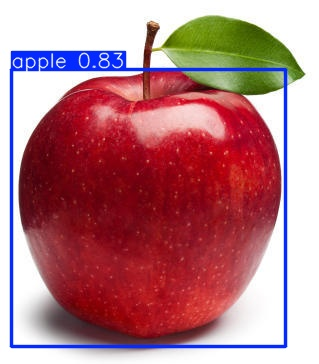

In [ ]:
from IPython.display import Image, display
import glob

hasil = glob.glob("runs/detect/predict/*.jpg")

display(Image(filename=hasil[0]))